# mmBERT-base baseline

This notebook fine-tunes [`jhu-clsp/mmBERT-base`](https://huggingface.co/jhu-clsp/mmBERT-base) for three-class German text classification.

The model distinguishes between:

- **Human-written text**
- **AI-generated text**
- **AI-assisted text**

Training uses the prepared Hugging Face dataset created for this project, with document-level train, validation, and test splits to reduce source leakage.

The notebook includes dataset preparation, tokenization, model training, probability calibration, evaluation, error analysis, length-bias analysis, and model export.

The notebook is designed to run with GPU acceleration. Required Python packages are installed in the setup cells when running in Google Colab.

In [22]:
import gc
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import time
from transformers.utils import logging as hf_logging
import torch
import transformers
from datasets import DatasetDict, load_dataset
from matplotlib.ticker import PercentFormatter
from sklearn.metrics import accuracy_score
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)

from peft import LoraConfig, TaskType, get_peft_model


## Load the training and validation data

In [5]:
import pandas as pd
from datasets import load_from_disk

dataset = load_from_disk(
    "hf-dataset-3class-full"
)

train_dataset = dataset["train"]
validation_dataset = dataset["validation"]
test_dataset = dataset["test"]

split_summary = pd.DataFrame(
    [
        {
            "split": name,
            "human": split["label"].count(0),
            "ai": split["label"].count(1),
            "ai_assisted": split["label"].count(2),
            "total": len(split),
        }
        for name, split in {
            "train": train_dataset,
            "validation": validation_dataset,
            "test": test_dataset,
        }.items()
    ]
).set_index("split")

split_summary

,human,ai,ai_assisted,total
split,,,,
train,8342,8324,8320,24986
validation,971,967,968,2906
test,914,912,911,2737


## Experiment Configuration

The experiment evaluates mmBERT-base using **1%, 5%, 12%, 17.5%, 25%, 50%, and 100%** of the available training data. The maximum sequence length is set to **512 tokens**.

In [13]:
RANDOM_STATE = 17
NUM_TRAIN_EPOCHS = 3

TRAIN_FRACTIONS = np.asarray(
    [0.01, 0.05, 0.12, 0.175, 0.25, 0.50, 1.00]
)

set_seed(RANDOM_STATE)

MODEL_NAME = "jhu-clsp/mmBERT-base"
MAX_LENGTH = 512

## 1. Tokenization

Load the mmBERT-base tokenizer and convert the text dataset into model-ready token sequences using a maximum length of 512 tokens and dynamic batch padding.

In [14]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    pad_to_multiple_of=8 if torch.cuda.is_available() else None,
)


def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )


curve_dataset = DatasetDict(
    {
        "train": train_dataset,
        "validation": validation_dataset,
    }
)

columns_to_remove = [
    column
    for column in train_dataset.column_names
    if column != "label"
]

tokenized_dataset = curve_dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=columns_to_remove,
    desc="Tokenizing",
)

tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 24986
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 2906
    })
})

## 2. Nested Training Order

Create a reproducible class-balanced ordering of the training samples so that larger learning-curve subsets contain all samples from the smaller subsets.

In [15]:
def build_stratified_order(
    labels,
    seed,
):
    labels = np.asarray(
        labels,
        dtype=np.int64,
    )

    rng = np.random.default_rng(
        seed
    )

    classes = np.unique(
        labels
    )

    class_indices = {}

    for class_id in classes:
        indices = np.flatnonzero(
            labels == class_id
        )

        rng.shuffle(
            indices
        )

        class_indices[
            class_id
        ] = indices.tolist()

    class_proportions = {
        class_id:
            len(class_indices[class_id])
            / len(labels)
        for class_id in classes
    }

    selected = {
        class_id: 0
        for class_id in classes
    }

    order = []

    for step in range(
        len(labels)
    ):
        available = [
            class_id
            for class_id in classes
            if selected[class_id]
            < len(
                class_indices[class_id]
            )
        ]

        next_class = max(
            available,
            key=lambda class_id:
                (
                    class_proportions[
                        class_id
                    ]
                    * (step + 1)
                    - selected[
                        class_id
                    ]
                ),
        )

        index_position = (
            selected[
                next_class
            ]
        )

        order.append(
            class_indices[
                next_class
            ][index_position]
        )

        selected[
            next_class
        ] += 1

    return np.asarray(
        order,
        dtype=np.int64,
    )


training_order = build_stratified_order(
    train_dataset["label"],
    seed=RANDOM_STATE,
)

## 3. Training Subsets

Define the training-set sizes used for the learning-curve experiment at 1%, 5%, 12%, 17.5%, 25%, 50%, and 100% of the available training data.

In [16]:
train_sizes = np.rint(
    TRAIN_FRACTIONS
    * len(train_dataset)
).astype(np.int64)

train_sizes = np.unique(
    np.clip(
        train_sizes,
        2,
        len(train_dataset),
    )
)

train_sizes[-1] = len(
    train_dataset
)


subset_summary = pd.DataFrame(
    {
        "training_samples":
            train_sizes,

        "training_fraction":
            train_sizes
            / len(train_dataset),
    }
)

subset_summary.style.format(
    {
        "training_fraction":
            "{:.1%}",
    }
)

,training_samples,training_fraction
0,250,1.0%
1,1249,5.0%
2,2998,12.0%
3,4373,17.5%
4,6246,25.0%
5,12493,50.0%
6,24986,100.0%


## 4. Model Initialization

Define a fresh mmBERT-base sequence-classification model for the three target classes: Human, AI, and AI-assisted.

In [17]:
ID_TO_LABEL = {
    0: "HUMAN",
    1: "AI",
    2: "AI_ASSISTED",
}

LABEL_TO_ID = {
    "HUMAN": 0,
    "AI": 1,
    "AI_ASSISTED": 2,
}


def create_mmbert_model():
    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=3,
        id2label=ID_TO_LABEL,
        label2id=LABEL_TO_ID,
    )

## 5. Experiment Output

Create directories for learning-curve results, checkpoints, and figures, and define the output paths used throughout the experiment.

In [18]:
OUTPUT_DIR = Path(
    "learning-curve-mmbert-base"
)

CHECKPOINT_DIR = (
    OUTPUT_DIR
    / "checkpoints"
)

RESULTS_DIR = (
    OUTPUT_DIR
    / "results"
)

FIGURES_DIR = (
    OUTPUT_DIR
    / "figures"
)

RESULTS_PATH = (
    RESULTS_DIR
    / "mmbert-base-learning-curve.csv"
)

for directory in [
    CHECKPOINT_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print(
    f"Training epochs per point: "
    f"{NUM_TRAIN_EPOCHS}"
)

print(
    f"Results file: "
    f"{RESULTS_PATH}"
)

Training epochs per point: 1
Results file: learning-curve-mmbert-base/results/mmbert-base-learning-curve.csv


## 6. Learning-Curve Experiment

Train a fresh mmBERT-base model on each training subset and measure training accuracy, validation accuracy, generalization gap, and training runtime.

In [23]:
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
hf_logging.set_verbosity_error()


learning_curve_rows = []

use_bf16 = (
    torch.cuda.is_available()
    and torch.cuda.is_bf16_supported()
)

for sample_count in train_sizes:
    sample_count = int(sample_count)

    train_indices = training_order[:sample_count]

    train_subset = tokenized_dataset["train"].select(
        train_indices.tolist()
    )

    set_seed(RANDOM_STATE)

    model = create_mmbert_model()

    training_args = TrainingArguments(
        output_dir=str(
            CHECKPOINT_DIR / f"samples-{sample_count}"
        ),
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        num_train_epochs=NUM_TRAIN_EPOCHS,
        weight_decay=0.01,
        eval_strategy="no",
        save_strategy="no",
        logging_strategy="epoch",
        bf16=use_bf16,
        fp16=(
            torch.cuda.is_available()
            and not use_bf16
        ),
        report_to="none",
        seed=RANDOM_STATE,
        data_seed=RANDOM_STATE,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_subset,
        processing_class=tokenizer,
        data_collator=data_collator,
    )

    print(
        f"\nTraining with {sample_count:,} samples"
    )

    start_time = time.perf_counter()

    trainer.train()

    runtime = (
        time.perf_counter()
        - start_time
    )

    train_output = trainer.predict(
        train_subset
    )

    validation_output = trainer.predict(
        tokenized_dataset["validation"]
    )

    training_accuracy = accuracy_score(
        train_output.label_ids,
        np.argmax(
            train_output.predictions,
            axis=1,
        ),
    )

    validation_accuracy = accuracy_score(
        validation_output.label_ids,
        np.argmax(
            validation_output.predictions,
            axis=1,
        ),
    )

    learning_curve_rows.append(
        {
            "training_samples": sample_count,
            "training_fraction":
                sample_count / len(train_dataset),
            "training_accuracy":
                training_accuracy,
            "validation_accuracy":
                validation_accuracy,
            "generalization_gap":
                training_accuracy
                - validation_accuracy,
            "training_runtime_seconds":
                runtime,
        }
    )

    print(
        f"Training accuracy: "
        f"{training_accuracy:.2%}; "
        f"validation accuracy: "
        f"{validation_accuracy:.2%}"
    )

    del trainer
    del model
    del train_subset
    del train_output
    del validation_output

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


mmbert_base_learning_curve = pd.DataFrame(
    learning_curve_rows
)

mmbert_base_learning_curve

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]


Training with 250 samples
{'loss': '1.099', 'grad_norm': '42.1', 'learning_rate': '6.25e-07', 'epoch': '1'}
{'train_runtime': '2.846', 'train_samples_per_second': '87.85', 'train_steps_per_second': '11.24', 'train_loss': '1.099', 'epoch': '1'}
Training accuracy: 76.80%; validation accuracy: 65.97%


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]


Training with 1,249 samples
{'loss': '0.5876', 'grad_norm': '12.85', 'learning_rate': '1.274e-07', 'epoch': '1'}
{'train_runtime': '13.72', 'train_samples_per_second': '91.05', 'train_steps_per_second': '11.45', 'train_loss': '0.5876', 'epoch': '1'}
Training accuracy: 94.40%; validation accuracy: 87.20%


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]


Training with 12,493 samples
{'loss': '0.3074', 'grad_norm': '72.27', 'learning_rate': '1.28e-08', 'epoch': '1'}
{'train_runtime': '134.3', 'train_samples_per_second': '93.03', 'train_steps_per_second': '11.63', 'train_loss': '0.3074', 'epoch': '1'}
Training accuracy: 97.97%; validation accuracy: 95.11%


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]


Training with 24,986 samples
{'loss': '0.2561', 'grad_norm': '0.00177', 'learning_rate': '6.402e-09', 'epoch': '1'}
{'train_runtime': '268.8', 'train_samples_per_second': '92.96', 'train_steps_per_second': '11.62', 'train_loss': '0.2561', 'epoch': '1'}
Training accuracy: 98.13%; validation accuracy: 96.25%


,training_samples,training_fraction,training_accuracy,validation_accuracy,generalization_gap,training_runtime_seconds
0,250,0.010006,0.768000,0.659670,0.108330,3.153045
1,1249,0.049988,0.943955,0.871989,0.071966,13.985929
2,2998,0.119987,0.963642,0.914315,0.049327,32.939703
3,4373,0.175018,0.977590,0.934274,0.043316,47.581977
4,6246,0.249980,0.977105,0.942189,0.034917,67.636123
5,12493,0.500000,0.979749,0.951136,0.028613,134.568050
6,24986,1.000000,0.981270,0.962491,0.018778,269.061235


## 7. Learning-Curve Results

Collect and format the performance measurements obtained for each training-set size.

In [27]:
mmbert_base_learning_curve = pd.DataFrame(
    learning_curve_rows
)

mmbert_base_learning_curve.to_csv(
    "mmbert-base-learning-curve.csv",
    index=False,
)

mmbert_base_learning_curve.style.format(
    {
        "training_fraction":
            "{:.1%}",

        "training_accuracy":
            "{:.2%}",

        "validation_accuracy":
            "{:.2%}",

        "generalization_gap":
            "{:.2%}",

        "training_runtime_seconds":
            "{:,.1f}",
    }
)

,training_samples,training_fraction,training_accuracy,validation_accuracy,generalization_gap,training_runtime_seconds
0,250,1.0%,76.80%,65.97%,10.83%,3.2
1,1249,5.0%,94.40%,87.20%,7.20%,14.0
2,2998,12.0%,96.36%,91.43%,4.93%,32.9
3,4373,17.5%,97.76%,93.43%,4.33%,47.6
4,6246,25.0%,97.71%,94.22%,3.49%,67.6
5,12493,50.0%,97.97%,95.11%,2.86%,134.6
6,24986,100.0%,98.13%,96.25%,1.88%,269.1


## 8. Learning-Curve Visualization

Plot training and validation accuracy against the percentage of training data used to visualize how mmBERT-base performance changes with dataset size.

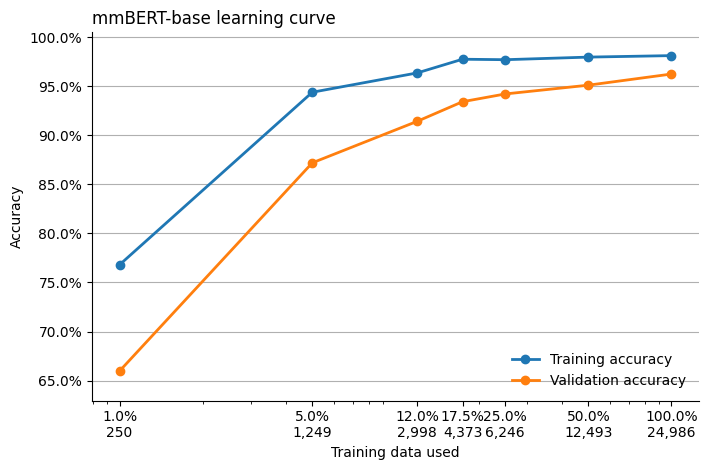

Saved figure to learning-curve-mmbert-base/figures/mmbert-base-learning-curve.svg


In [26]:
mmbert_base_learning_curve = (
    mmbert_base_learning_curve
    .sort_values("training_fraction")
    .reset_index(drop=True)
)

x_percent = (
    mmbert_base_learning_curve[
        "training_fraction"
    ].to_numpy()
    * 100
)

training_accuracy = (
    mmbert_base_learning_curve[
        "training_accuracy"
    ].to_numpy()
)

validation_accuracy = (
    mmbert_base_learning_curve[
        "validation_accuracy"
    ].to_numpy()
)

fig, ax = plt.subplots(
    figsize=(7.2, 4.8)
)

ax.plot(
    x_percent,
    training_accuracy,
    marker="o",
    linewidth=2,
    label="Training accuracy",
)

ax.plot(
    x_percent,
    validation_accuracy,
    marker="o",
    linewidth=2,
    label="Validation accuracy",
)

ax.set_xscale(
    "log"
)

ax.set_xticks(
    x_percent,
    [
        (
            f"{fraction:.1f}%\n"
            f"{samples:,}"
        )
        for fraction, samples
        in zip(
            x_percent,
            mmbert_base_learning_curve[
                "training_samples"
            ],
        )
    ],
)

lower_limit = max(
    0.5,
    min(
        training_accuracy.min(),
        validation_accuracy.min(),
    )
    - 0.03,
)

ax.set_ylim(
    lower_limit,
    1.005,
)

ax.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

ax.set_xlabel(
    "Training data used"
)

ax.set_ylabel(
    "Accuracy"
)

ax.set_title(
    "mmBERT-base learning curve",
    loc="left",
)

ax.grid(
    axis="y",
    linewidth=0.8,
)

ax.spines[
    ["top", "right"]
].set_visible(
    False
)

ax.legend(
    frameon=False,
    loc="lower right",
)

fig.tight_layout()

FIGURE_PATH = (
    FIGURES_DIR
    / "mmbert-base-learning-curve.svg"
)

fig.savefig(
    FIGURE_PATH,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved figure to "
    f"{FIGURE_PATH}"
)